## 0. Library Importation

In [1]:
# Gestion du système et des fichiers
import os
import sys
import subprocess

# Manipulation des données XML (Sorties de SUMO)
import xml.etree.ElementTree as ET

# Analyse de données
import pandas as pd
import numpy as np

# Visualisation et Graphiques
import matplotlib.pyplot as plt
import seaborn as sns
import traci

# Configuration optionnelle pour rendre les graphiques plus jolis
sns.set_theme(style="whitegrid")
sys.path.append('src/')

from utils import launch_simulation, analyze_tripinfo, analyze_pollution, analyze_queue, analyze_network_speed

## 1. Simulation Execution

In [2]:
#Dictionnary of our concerned junctions with their incoming and outgoing edges
dict_junctions = {}

dict_junctions['B2_in'] = ['A2B2', 'C2B2', 'B3B2', 'B1B2']
dict_junctions['B2_out'] = ['B2A2', 'B2C2', 'B2B3', 'B2B1']

dict_junctions['B3_in'] = ['A3B3','C3B3','B4B3','B2B3']
dict_junctions['B3_out'] = ['B3A3','B3C3','B3B4','B3B2']

dict_junctions['C3_in'] = ['D3C3','B3C3','C4C3','C2C3']
dict_junctions['C3_out'] = ['C3D3','C3B3','C3C4','C3C2']

dict_junctions


{'B2_in': ['A2B2', 'C2B2', 'B3B2', 'B1B2'],
 'B2_out': ['B2A2', 'B2C2', 'B2B3', 'B2B1'],
 'B3_in': ['A3B3', 'C3B3', 'B4B3', 'B2B3'],
 'B3_out': ['B3A3', 'B3C3', 'B3B4', 'B3B2'],
 'C3_in': ['D3C3', 'B3C3', 'C4C3', 'C2C3'],
 'C3_out': ['C3D3', 'C3B3', 'C3C4', 'C3C2']}

# 2 Reinforcment Learning Traffic Light Control

## 2.1 3 different agents for 3 different intersections: B2, B3, C3

In [3]:
from tracemalloc import stop
import traci
import torch
import torch.nn as nn
import torch.optim as optim
import csv
import os
from brain import TrafficBrain, MultipleTrafficBrains

# --- SETTINGS ---
EPISODES = 1000
STEPS_PER_EPISODE = 2000
CSV_FILE = "training_log.csv"
MODEL_DIR = "models_without_yellow"
YELLOW_DURATION = 0  # Seconds for yellow light

if not os.path.exists(MODEL_DIR): os.makedirs(MODEL_DIR)


# Initialize CSV
with open('outputs/' + CSV_FILE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["episode", "avg_waiting_time", "total_reward"])

def get_state(edge_id, in_and_out=False):
    if in_and_out:
        in_edges = edge_id + "_in"
        out_edges = edge_id + "_out"
        q_in_e = traci.edge.getLastStepHaltingNumber(dict_junctions[in_edges][0])
        q_in_n = traci.edge.getLastStepHaltingNumber(dict_junctions[in_edges][1])
        q_in_w = traci.edge.getLastStepHaltingNumber(dict_junctions[in_edges][2])
        q_in_s = traci.edge.getLastStepHaltingNumber(dict_junctions[in_edges][3])
        q_out_e = traci.edge.getLastStepHaltingNumber(dict_junctions[out_edges][0])
        q_out_n = traci.edge.getLastStepHaltingNumber(dict_junctions[out_edges][1])
        q_out_w = traci.edge.getLastStepHaltingNumber(dict_junctions[out_edges][2])
        q_out_s = traci.edge.getLastStepHaltingNumber(dict_junctions[out_edges][3])
        return torch.FloatTensor([q_in_n/50, q_in_s/50, q_in_e/50, q_in_w/50,
                                  q_out_n/50, q_out_s/50, q_out_e/50, q_out_w/50])
    else:
        q_n = traci.edge.getLastStepHaltingNumber(dict_junctions[edge_id + "_in"][0])
        q_s = traci.edge.getLastStepHaltingNumber(dict_junctions[edge_id + "_in"][3])
        q_e = traci.edge.getLastStepHaltingNumber(dict_junctions[edge_id + "_in"][0])
        q_w = traci.edge.getLastStepHaltingNumber(dict_junctions[edge_id + "_in"][2])
        return torch.FloatTensor([q_n/50, q_s/50, q_e/50, q_w/50])

def set_phase(junction_id, target_phase, safe=False):
    """
    Switches traffic light safely or not.
    If we are Green on NS and want to go Green EW, we MUST show Yellow first.
    SUMO Phases (Standard Guess):
    0: NS Green (GrGr)
    1: NS Yellow (yryr)
    2: EW Green (rGrG)
    3: EW Yellow (ryry)
    """
    current_phase = traci.trafficlight.getPhase(junction_id)
    

    # If we are already in the target phase, do nothing
    if current_phase == target_phase:
        return
    elif safe:
        # If we need to switch, calculate the Yellow phase index
        # (Usually current_phase + 1 is the yellow for that direction)
        yellow_phase = current_phase + 1
        
        # 1. Switch to Yellow
        traci.trafficlight.setPhase(junction_id, yellow_phase)
        
        # 2. Hold Yellow for 3 seconds (simulate 3 steps)
        for _ in range(YELLOW_DURATION):
            traci.simulationStep()
            
        # 3. Finally switch to the new Green target
        traci.trafficlight.setPhase(junction_id, target_phase)
    else:
        traci.trafficlight.setPhase(junction_id, target_phase)

brain_B2 = TrafficBrain()
brain_B3 = TrafficBrain()
brain_C3 = TrafficBrain()
optimizer_B2 = optim.Adam(brain_B2.parameters(), lr=0.001)
optimizer_B3 = optim.Adam(brain_B3.parameters(), lr=0.001)
optimizer_C3 = optim.Adam(brain_C3.parameters(), lr=0.001)

# --- TRAINING LOOP ---
print(f"Starting Training...")


best_reward = -float('inf')

def main():

    for episode in range(1, EPISODES + 1):
        traci.start(["sumo", "-c", "SUMO_net/ff_heterogeneous.sumocfg"])
        
        total_reward = 0
        total_waiting_time = 0
        step = 0
        
        while step < STEPS_PER_EPISODE:
            # A. OBSERVE
            state_B2 = get_state('B2', in_and_out=False)
            state_B3 = get_state('B3', in_and_out=False)
            state_C3 = get_state('C3', in_and_out=False)
            
            # B. THINK & ACT
            probs_B2 = brain_B2(state_B2)
            probs_B3 = brain_B3(state_B3)
            probs_C3 = brain_C3(state_C3)
            action_B2 = torch.multinomial(probs_B2, 1).item()
            action_B3 = torch.multinomial(probs_B3, 1).item()
            action_C3 = torch.multinomial(probs_C3, 1).item()


            
            # Action 0 = NS Green (Phase 0), Action 1 = EW Green (Phase 2)
            target_phase_B2 = 0 if action_B2 == 0 else 2
            target_phase_B3 = 0 if action_B3 == 0 else 2
            target_phase_C3 = 0 if action_C3 == 0 else 2
            
            # Use our safe switcher (handles Yellow automatically)
            set_phase("B2", target_phase_B2)
            set_phase("B3", target_phase_B3)
            set_phase("C3", target_phase_C3)
            
            # Run 1 step of Green (Yellow steps were handled inside the function)
            traci.simulationStep()
            step += 1 + YELLOW_DURATION # We advanced time, so update counter
            
            # C. REWARD
            waiting = 0
            for edge_id in dict_junctions['B2_in'] + dict_junctions['B3_in'] + dict_junctions['C3_in']:
                waiting += traci.edge.getWaitingTime(edge_id)
            
            reward = -waiting
            total_reward += reward
            total_waiting_time += waiting
            
            # D. LEARN (Backpropagation)
            loss_B2 = -torch.log(probs_B2[action_B2]) * reward
            optimizer_B2.zero_grad()
            loss_B2.backward()
            optimizer_B2.step()

            loss_B3 = -torch.log(probs_B3[action_B3]) * reward
            optimizer_B3.zero_grad()
            loss_B3.backward()
            optimizer_B3.step()

            loss_C3 = -torch.log(probs_C3[action_C3]) * reward
            optimizer_C3.zero_grad()
            loss_C3.backward()
            optimizer_C3.step()
        
        traci.close()
        
        avg_wait = total_waiting_time / step
        print(f"Episode {episode}: Avg Wait={avg_wait:.2f}s | Total Reward={total_reward}")
        
        with open(CSV_FILE, "a", newline="") as f:
            csv.writer(f).writerow([episode, avg_wait, total_reward])

        if total_reward > best_reward:
            best_reward = total_reward
            brain_B2.save(f"{MODEL_DIR}/policy_B2_ep{episode}.pth")
            brain_B3.save(f"{MODEL_DIR}/policy_B3_ep{episode}.pth")
            brain_C3.save(f"{MODEL_DIR}/policy_C3_ep{episode}.pth")

        elif episode % 500 == 0:
            brain_B2.save(f"{MODEL_DIR}/policy_B2_ep{episode}.pth")
            brain_B3.save(f"{MODEL_DIR}/policy_B3_ep{episode}.pth")
            brain_C3.save(f"{MODEL_DIR}/policy_C3_ep{episode}.pth")
        elif episode == EPISODES:
            brain_B2.save(f"{MODEL_DIR}/final_policy_B2.pth")
            brain_B3.save(f"{MODEL_DIR}/final_policy_B3.pth")
            brain_C3.save(f"{MODEL_DIR}/final_policy_C3.pth")

    print("Done.")

# if __name__ == "__main__":
#     main()


Starting Training...


## 2.2 One agent for all intersections

In [ ]:
from tracemalloc import stop
import traci
import torch
import torch.nn as nn
import torch.optim as optim
import csv
import os
from brain import TrafficBrain, MultipleTrafficBrains

# --- SETTINGS ---
EPISODES = 1000
STEPS_PER_EPISODE = 2000
CSV_FILE = "training_log_one_agent.csv"
MODEL_DIR = "models_one_agent_without_yellow"
YELLOW_DURATION = 3  # Seconds for yellow light



if not os.path.exists(MODEL_DIR): os.makedirs(MODEL_DIR)


# Initialize CSV
with open('outputs/' + CSV_FILE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["episode", "avg_waiting_time", "total_reward"])

def get_local_state(junction_id):
    q_n = traci.edge.getLastStepHaltingNumber(dict_junctions[junction_id + "_in"][0])
    q_s = traci.edge.getLastStepHaltingNumber(dict_junctions[junction_id + "_in"][3])
    q_e = traci.edge.getLastStepHaltingNumber(dict_junctions[junction_id + "_in"][1])
    q_w = traci.edge.getLastStepHaltingNumber(dict_junctions[junction_id + "_in"][2])
    return [q_n, q_s, q_e, q_w]

def get_global_state():
    state_b2 = get_local_state('B2') 
    state_b3 = get_local_state('B3')
    state_c3 = get_local_state('C3')
    
    # On fusionne tout en un seul tenseur
    global_state = torch.tensor(state_b2 + state_b3 + state_c3, dtype=torch.float32)
    return global_state

def set_phase(junction_id, target_phase, safe=False):
    """
    Switches traffic light safely or not.
    If we are Green on NS and want to go Green EW, we MUST show Yellow first.
    SUMO Phases (Standard Guess):
    0: NS Green (GrGr)
    1: NS Yellow (yryr)
    2: EW Green (rGrG)
    3: EW Yellow (ryry)
    """
    current_phase = traci.trafficlight.getPhase(junction_id)
    

    # If we are already in the target phase, do nothing
    if current_phase == target_phase:
        return
    elif safe:
        # If we need to switch, calculate the Yellow phase index
        # (Usually current_phase + 1 is the yellow for that direction)
        yellow_phase = current_phase + 1
        
        # 1. Switch to Yellow
        traci.trafficlight.setPhase(junction_id, yellow_phase)
        
        # 2. Hold Yellow for 3 seconds (simulate 3 steps)
        for _ in range(YELLOW_DURATION):
            traci.simulationStep()
            
        # 3. Finally switch to the new Green target
        traci.trafficlight.setPhase(junction_id, target_phase)
    else:
        traci.trafficlight.setPhase(junction_id, target_phase)






# Liste des 8 combinaisons possibles : [B2, B3, C3]
ACTION_MAP = [
    [0, 0, 0], # Action 0
    [0, 0, 1], # Action 1
    [0, 1, 0], # Action 2
    [0, 1, 1], # Action 3
    [1, 0, 0], # Action 4
    [1, 0, 1], # Action 5
    [1, 1, 0], # Action 6
    [1, 1, 1]  # Action 7
]

# --- TRAINING LOOP ---
print(f"Starting Training...")

brain = MultipleTrafficBrains()
optimizer = optim.Adam(brain.parameters(), lr=0.001)

def main():

    best_reward = -float('inf')

    for episode in range(1, EPISODES + 1):
        traci.start(["sumo", "-c", "SUMO_net/ff_heterogeneous.sumocfg"])
        
        total_reward = 0
        total_waiting_time = 0
        step = 0
        
        while step < STEPS_PER_EPISODE:

            # A. OBSERVE 
            state = get_global_state() 

            # B. THINK 
            probs = brain(state)
            action_idx = torch.multinomial(probs, 1).item() # Donne un chiffre entre 0 et 7

            # C. DECODE 
            phases = ACTION_MAP[action_idx] 

            # On traduit 0/1 en vrais index de phases SUMO (0 ou 2 comme avant)
            target_B2 = 0 if phases[0] == 0 else 2
            target_B3 = 0 if phases[1] == 0 else 2
            target_C3 = 0 if phases[2] == 0 else 2

            # D. ACT 
            set_phase("B2", target_B2)
            set_phase("B3", target_B3)
            set_phase("C3", target_C3)

            traci.simulationStep()

            # E.REWARD
            waiting = 0
            for edge_id in dict_junctions['B2_in'] + dict_junctions['B3_in'] + dict_junctions['C3_in']:
                waiting += traci.edge.getWaitingTime(edge_id)
            reward = -waiting
            total_reward += reward
            total_waiting_time += waiting
            step += 1
            

            # F. LEARN
            loss = -torch.log(probs[action_idx]) * reward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        
        traci.close()
        
        avg_wait = total_waiting_time / step
        print(f"Episode {episode}: Avg Wait={avg_wait:.2f}s | Total Reward={total_reward}")
        
        with open(CSV_FILE, "a", newline="") as f:
            csv.writer(f).writerow([episode, avg_wait, total_reward])

        if total_reward > best_reward:
            best_reward = total_reward
            brain.save(f"{MODEL_DIR}/policy_ep{episode}.pth")

        elif episode % 500 == 0:
            brain.save(f"{MODEL_DIR}/policy_ep{episode}.pth")

        elif episode == EPISODES:
            brain.save(f"{MODEL_DIR}/final_policy.pth")

    print("Done.")

# if __name__ == "__main__":
#     main()

Starting Training...


# 3. Simulations

## 3.1 Multi-AI and Normal Simulations

In [36]:
import traci
import torch
import os
import sys
from brain import TrafficBrain, MultipleTrafficBrains

# --- SETTINGS ---
MODEL_PATH_B2 = "models_without_yellow/policy_B2_ep4380.pth" 
MODEL_PATH_B3 = "models_without_yellow/policy_B3_ep4380.pth" 
MODEL_PATH_C3 = "models_without_yellow/policy_C3_ep4380.pth" 
YELLOW_DURATION = 3
SIM_DURATION = 2000  

def get_state(edge_id, in_and_out=False):
    if in_and_out:
        in_edges = edge_id + "_in"
        out_edges = edge_id + "_out"
        q_in_e = traci.edge.getLastStepHaltingNumber(dict_junctions[in_edges][0])
        q_in_n = traci.edge.getLastStepHaltingNumber(dict_junctions[in_edges][1])
        q_in_w = traci.edge.getLastStepHaltingNumber(dict_junctions[in_edges][2])
        q_in_s = traci.edge.getLastStepHaltingNumber(dict_junctions[in_edges][3])
        q_out_e = traci.edge.getLastStepHaltingNumber(dict_junctions[out_edges][0])
        q_out_n = traci.edge.getLastStepHaltingNumber(dict_junctions[out_edges][1])
        q_out_w = traci.edge.getLastStepHaltingNumber(dict_junctions[out_edges][2])
        q_out_s = traci.edge.getLastStepHaltingNumber(dict_junctions[out_edges][3])
        return torch.FloatTensor([q_in_n/50, q_in_s/50, q_in_e/50, q_in_w/50,
                                  q_out_n/50, q_out_s/50, q_out_e/50, q_out_w/50])
    else:
        q_n = traci.edge.getLastStepHaltingNumber(dict_junctions[edge_id + "_in"][0])
        q_s = traci.edge.getLastStepHaltingNumber(dict_junctions[edge_id + "_in"][3])
        q_e = traci.edge.getLastStepHaltingNumber(dict_junctions[edge_id + "_in"][0])
        q_w = traci.edge.getLastStepHaltingNumber(dict_junctions[edge_id + "_in"][2])
        return torch.FloatTensor([q_n/50, q_s/50, q_e/50, q_w/50])



# --- SIMULATION RUNNER ---
def run_simulation(mode="AI", output_file="tripinfo_ai.xml"):
    print(f"Running Simulation in {mode} mode...")
    
    sumo_cmd = [
    "sumo-gui", "-c", "SUMO_net/ff_heterogeneous.sumocfg",
    
    # Statistiques voyage / CO2
    "--tripinfo-output", "outputs/tripinfo_" + output_file,
    "--emission-output", "outputs/emissions_" + output_file,
    
    # Collisions
    "--collision-output", "outputs/collisions_" + output_file,
    
    # Changements de feux
    # "--tls-switch-output", "outputs/tls_switches_" + output_file,
    "--queue-output", "outputs/queues_" + output_file
]
    traci.start(sumo_cmd)
    
    # Load AI
    brain = None
    if mode == "AI":
        brain_B2 = MultipleTrafficBrains()
        brain_B3 = MultipleTrafficBrains()
        brain_C3 = MultipleTrafficBrains()
        if os.path.exists(MODEL_PATH_B2) and os.path.exists(MODEL_PATH_B3) and os.path.exists(MODEL_PATH_C3):
            brain_B2.load(MODEL_PATH_B2)
            brain_B3.load(MODEL_PATH_B3)
            brain_C3.load(MODEL_PATH_C3)
            brain_B2.eval()
            brain_B3.eval()
            brain_C3.eval()
        else:
            print(f"ERROR: Model {MODEL_PATH_B2}, {MODEL_PATH_B3}, or {MODEL_PATH_C3} not found!")
            traci.close()
            sys.exit()
    
    # --- FIXED LOOP ---
    # We use SUMO's internal clock to stop exactly at 3000
    while traci.simulation.getTime() < SIM_DURATION:
        
        if mode == "AI":
            state_B2 = get_state('B2', in_and_out=False)
            state_B3 = get_state('B3', in_and_out=False)
            state_C3 = get_state('C3', in_and_out=False)
            
            probs_B2 = brain_B2(state_B2)
            probs_B3 = brain_B3(state_B3)
            probs_C3 = brain_C3(state_C3)
            action_B2 = torch.argmax(probs_B2).item()
            action_B3 = torch.argmax(probs_B3).item()
            action_C3 = torch.argmax(probs_C3).item()
            
            target_phase_B2 = 0 if action_B2 == 0 else 2
            target_phase_B3 = 0 if action_B3 == 0 else 2
            target_phase_C3 = 0 if action_C3 == 0 else 2
            
            # The function now handles the simulation steps for yellow internally
            # We don't need to manually add to a counter
            set_phase("B2", target_phase_B2)
            set_phase("B3", target_phase_B3)
            set_phase("C3", target_phase_C3)
            
        # Advance 1 step for the Green light duration
        # (This is the normal step that happens every second)
        traci.simulationStep()
    
    traci.close()
    print(f"Finished {mode}. Saved to {output_file}")

if __name__ == "__main__":
    #run_simulation(mode="AI", output_file="multi_agent_ai_4380_epochs.xml")
    run_simulation(mode="Normal", output_file="normal.xml")
    print("\n✅ Done! Now run 'compare_results.py'")

Running Simulation in Normal mode...
Finished Normal. Saved to normal.xml

✅ Done! Now run 'compare_results.py'


## 3.2 Max Pressure Simulations

In [31]:
# Max Pressure Simulation
import traci
import torch
import os
import sys

dict_max_pressure = {}
dict_max_pressure['B2_in'] = ['A2B2_0','A2B2_1','A2B2_2', 'C2B2_0','C2B2_1','C2B2_2', 'B3B2_0','B3B2_1','B3B2_2', 'B1B2_0','B1B2_1','B1B2_2']
dict_max_pressure['B2_out'] = ['B2A2_0', 'B2A2_1', 'B2A2_2', 'B2C2_0', 'B2C2_1', 'B2C2_2', 'B2B3_0', 'B2B3_1', 'B2B3_2', 'B2B1_0', 'B2B1_1', 'B2B1_2']

dict_max_pressure['B3_in'] = ['A3B3_0','A3B3_1','A3B3_2','C3B3_0','C3B3_1','C3B3_2','B4B3_0','B4B3_1','B4B3_2','B2B3_0','B2B3_1','B2B3_2']
dict_max_pressure['B3_out'] = ['B3A3_0','B3A3_1','B3A3_2','B3C3_0','B3C3_1','B3C3_2','B3B4_0','B3B4_1','B3B4_2','B3B2_0','B3B2_1','B3B2_2']

dict_max_pressure['C3_in'] = ['D3C3_0','D3C3_1','D3C3_2','B3C3_0','B3C3_1','B3C3_2','C4C3_0','C4C3_1','C4C3_2','C2C3_0','C2C3_1','C2C3_2']
dict_max_pressure['C3_out'] = ['C3D3_0','C3D3_1','C3D3_2','C3B3_0','C3B3_1','C3B3_2','C3C4_0','C3C4_1','C3C4_2','C3C2_0','C3C2_1','C3C2_2']


SUMO_CMD = ["sumo-gui", "-c", "SUMO_net/ff_heterogeneous.sumocfg", 
            "--tripinfo-output", "outputs/tripinfo_maxpressure.xml",
            "--collision-output", "outputs/collisions_maxpressure.xml",
            "--emission-output", "outputs/emissions_maxpressure.xml",
            "--queue-output", "outputs/queues_maxpressure.xml"]


PHASE_NS_GREEN = 0
PHASE_EW_GREEN = 2


def get_pressure(lanes_in, lanes_out):
    pressure_in = 0
    pressure_out = 0
    for lane in lanes_in:
        pressure_in += traci.lane.getLastStepVehicleNumber(lane)
    for lane in lanes_out:
        pressure_out += traci.lane.getLastStepVehicleNumber(lane)
    return  pressure_in - pressure_out


def run():
    traci.start(SUMO_CMD)
    step = 0
    while step < 2000:
        traci.simulationStep()
        pressures_B2 = {}
        pressures_B3 = {}
        pressures_C3 = {}
        if step % 5 == 0:
            pressures_B2[PHASE_NS_GREEN] = get_pressure(dict_max_pressure['B2_in'], dict_max_pressure['B2_out'])
            pressures_B2[PHASE_EW_GREEN] = get_pressure(dict_max_pressure['B2_in'], dict_max_pressure['B2_out'])

            pressures_B3[PHASE_NS_GREEN] = get_pressure(dict_max_pressure['B3_in'], dict_max_pressure['B3_out'])
            pressures_B3[PHASE_EW_GREEN] = get_pressure(dict_max_pressure['B3_in'], dict_max_pressure['B3_out'])
            pressures_C3[PHASE_NS_GREEN] = get_pressure(dict_max_pressure['C3_in'], dict_max_pressure['C3_out'])
            pressures_C3[PHASE_EW_GREEN] = get_pressure(dict_max_pressure['C3_in'], dict_max_pressure['C3_out'])

            best_phase_B2 = max(pressures_B2, key=pressures_B2.get)
            best_phase_B3 = max(pressures_B3, key=pressures_B3.get)
            best_phase_C3 = max(pressures_C3, key=pressures_C3.get) 

            traci.trafficlight.setPhase('B2', best_phase_B2)
            traci.trafficlight.setPhase('B3', best_phase_B3)
            traci.trafficlight.setPhase('C3', best_phase_C3)
        step += 1
    traci.close()

if __name__ == "__main__":
    run()

## 3.3 One AI for all intersections Simulation

In [ ]:
import traci
import torch
import os
import sys
from brain import TrafficBrain

# --- SETTINGS ---
MODEL_PATH = "models_one_agent_without_yellow/policy_ep1000.pth"
 
YELLOW_DURATION = 0
SIM_DURATION = 2000  


        #Dictionnary of our concerned junctions with their incoming and outgoing edges
dict_junctions = {}

dict_junctions['B2_in'] = ['A2B2', 'C2B2', 'B3B2', 'B1B2']
dict_junctions['B2_out'] = ['B2A2', 'B2C2', 'B2B3', 'B2B1']

dict_junctions['B3_in'] = ['A3B3','C3B3','B4B3','B2B3']
dict_junctions['B3_out'] = ['B3A3','B3C3','B3B4','B3B2']

dict_junctions['C3_in'] = ['D3C3','B3C3','C4C3','C2C3']
dict_junctions['C3_out'] = ['C3D3','C3B3','C3C4','C3C2']

dict_junctions

# --- SIMULATION RUNNER ---
def run_simulation(output_file="tripinfo_ai.xml"):
    print(f"Running Simulation...")
    
    sumo_cmd = [
    "sumo-gui", "-c", "SUMO_net/ff_heterogeneous.sumocfg",
    
    # Statistiques voyage / CO2
    "--tripinfo-output", "outputs/tripinfo_" + output_file,
    "--emission-output", "outputs/emissions_" + output_file,
    
    # Collisions
    "--collision-output", "outputs/collisions_" + output_file,
    
    # Changements de feux
    # "--tls-switch-output", "outputs/tls_switches_" + output_file,
    "--queue-output", "outputs/queues_" + output_file
]
    

    traci.start(sumo_cmd)
    

    brain = TrafficBrain()

    brain.load(MODEL_PATH)

    brain.eval()


    
    # --- FIXED LOOP ---
    # We use SUMO's internal clock to stop exactly at 3000
    while traci.simulation.getTime() < SIM_DURATION:
        
        def groupe_3():

            def get_local_state(junction_id):
                q_n = traci.edge.getLastStepHaltingNumber(dict_junctions[junction_id + "_in"][0])
                q_s = traci.edge.getLastStepHaltingNumber(dict_junctions[junction_id + "_in"][3])
                q_e = traci.edge.getLastStepHaltingNumber(dict_junctions[junction_id + "_in"][1])
                q_w = traci.edge.getLastStepHaltingNumber(dict_junctions[junction_id + "_in"][2])
                return [q_n, q_s, q_e, q_w]

            def get_global_state():
                state_b2 = get_local_state('B2') 
                state_b3 = get_local_state('B3')
                state_c3 = get_local_state('C3')
                
                # On fusionne tout en un seul tenseur
                global_state = torch.tensor(state_b2 + state_b3 + state_c3, dtype=torch.float32)
                return global_state

            def set_phase(junction_id, target_phase, safe=False):
                """
                Switches traffic light safely or not.
                If we are Green on NS and want to go Green EW, we MUST show Yellow first.
                SUMO Phases (Standard Guess):
                0: NS Green (GrGr)
                1: NS Yellow (yryr)
                2: EW Green (rGrG)
                3: EW Yellow (ryry)
                """
                current_phase = traci.trafficlight.getPhase(junction_id)
                

                # If we are already in the target phase, do nothing
                if current_phase == target_phase:
                    return
                elif safe:
                    # If we need to switch, calculate the Yellow phase index
                    # (Usually current_phase + 1 is the yellow for that direction)
                    yellow_phase = current_phase + 1
                    
                    # 1. Switch to Yellow
                    traci.trafficlight.setPhase(junction_id, yellow_phase)
                    
                    # 2. Hold Yellow for 3 seconds (simulate 3 steps)
                    for _ in range(YELLOW_DURATION):
                        traci.simulationStep()
                        
                    # 3. Finally switch to the new Green target
                    traci.trafficlight.setPhase(junction_id, target_phase)
                else:
                    traci.trafficlight.setPhase(junction_id, target_phase)






            # Liste des 8 combinaisons possibles : [B2, B3, C3]
            ACTION_MAP = [
                [0, 0, 0], # Action 0
                [0, 0, 1], # Action 1
                [0, 1, 0], # Action 2
                [0, 1, 1], # Action 3
                [1, 0, 0], # Action 4
                [1, 0, 1], # Action 5
                [1, 1, 0], # Action 6
                [1, 1, 1]  # Action 7
            ]

    
            state = get_global_state()
            
            probs = brain(state)
            
            action_idx = torch.argmax(probs).item()
            
            # C. DECODE 
            phases = ACTION_MAP[action_idx]
        
            # On traduit 0/1 en vrais index de phases SUMO (0 ou 2 comme avant)
            target_B2 = 0 if phases[0] == 0 else 2
            target_B3 = 0 if phases[1] == 0 else 2
            target_C3 = 0 if phases[2] == 0 else 2

            # D. ACT 
            set_phase("B2", target_B2)
            set_phase("B3", target_B3)
            set_phase("C3", target_C3)

            traci.simulationStep()
        groupe_3()
    
    traci.close()
    print(f"Finished. Saved to {output_file}")

if __name__ == "__main__":
    run_simulation(output_file="one_agent_ai_1000_epochs.xml")
    print("\n✅ Done! Now run 'compare_results.py'")

Running Simulation...
Finished. Saved to one_agent_ai_1000_epochs.xml

✅ Done! Now run 'compare_results.py'


# 4. Results Analysis and Visualization


METRIQUE             | NORMAL       | MAX PRESS    | MULTI AGENT  | ONE AGENT   
-------------------------------------------------------------------------------------
Avg Waiting Time     | 109.65s      | 107.76s      | 102.51s      |  99.52s
Avg Time Loss        | 155.38s      | 149.21s      | 148.48s      | 147.44s
Avg Trip Duration    | 267.19s      | 266.80s      | 263.72s      | 259.64s

Graphique sauvegardé : outputs/comparison_result.png


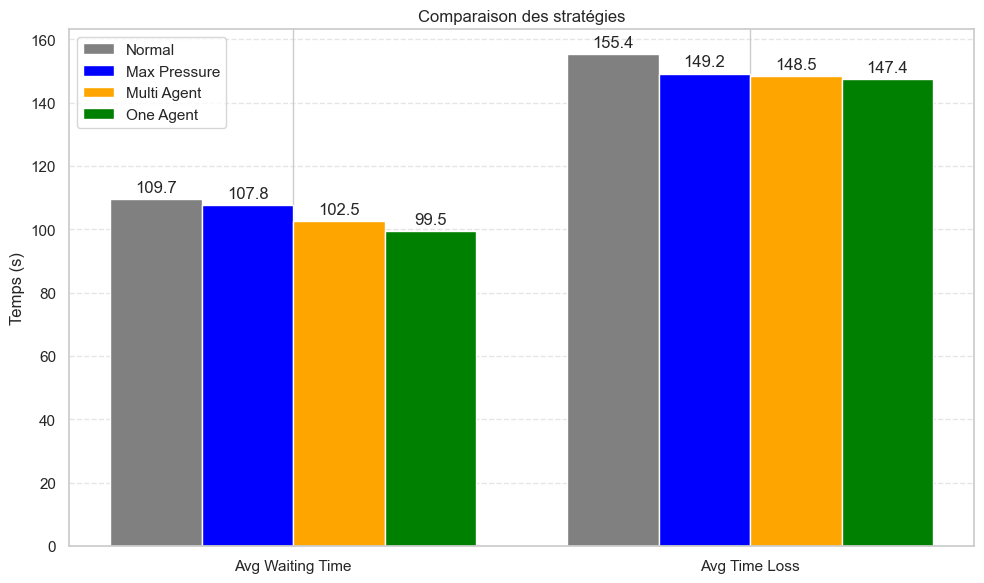

In [37]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
import os

def parse_tripinfo(filename):
    # Lecture du fichier XML généré par SUMO
    if not os.path.exists(filename):
        print(f"Fichier introuvable : {filename}")
        return None

    try:
        tree = ET.parse(filename)
        root = tree.getroot()
    except:
        print(f"Erreur de lecture sur {filename}")
        return None

    durations = []
    waiting_times = []
    time_losses = []

    # On récupère les stats pour chaque véhicule
    for trip in root.findall('tripinfo'):
        durations.append(float(trip.get('duration')))
        waiting_times.append(float(trip.get('waitingTime')))
        time_losses.append(float(trip.get('timeLoss')))

    total = len(durations)
    if total == 0:
        return {"avg_wait": 0, "avg_loss": 0, "avg_duration": 0}

    # Calcul des moyennes
    return {
        "avg_wait": sum(waiting_times) / total,
        "avg_loss": sum(time_losses) / total,
        "avg_duration": sum(durations) / total
    }

def print_comparison(normal, max_pressure, multi_agent, one_agent):
    # Affichage tableau comparatif console
    print("\n" + "="*85)
    print(f"{'METRIQUE':<20} | {'NORMAL':<12} | {'MAX PRESS':<12} | {'MULTI AGENT':<12} | {'ONE AGENT':<12}")
    print("-" * 85)
    
    metrics = [
        ("Avg Waiting Time", "avg_wait", "s"),
        ("Avg Time Loss", "avg_loss", "s"),
        ("Avg Trip Duration", "avg_duration", "s")
    ]

    for label, key, unit in metrics:
        v1 = normal[key]
        v2 = max_pressure[key]
        v3 = multi_agent[key]
        v4 = one_agent[key]

        print(f"{label:<20} | {v1:6.2f}{unit}      | {v2:6.2f}{unit}      | {v3:6.2f}{unit}      | {v4:6.2f}{unit}")
    
    print("="*85 + "\n")

def plot_comparison(normal, max_pressure, multi_agent, one_agent):
    # Création du graphique en barres
    labels = ['Avg Waiting Time', 'Avg Time Loss']
    
    vals_norm = [normal['avg_wait'], normal['avg_loss']]
    vals_mp = [max_pressure['avg_wait'], max_pressure['avg_loss']]
    vals_multi = [multi_agent['avg_wait'], multi_agent['avg_loss']]
    vals_one = [one_agent['avg_wait'], one_agent['avg_loss']]

    x = np.arange(len(labels))
    width = 0.20

    fig, ax = plt.subplots(figsize=(10, 6))

    # Positionnement des 4 barres
    rects1 = ax.bar(x - 1.5*width, vals_norm, width, label='Normal', color='gray')
    rects2 = ax.bar(x - 0.5*width, vals_mp, width, label='Max Pressure', color='blue')
    rects3 = ax.bar(x + 0.5*width, vals_multi, width, label='Multi Agent', color='orange')
    rects4 = ax.bar(x + 1.5*width, vals_one, width, label='One Agent', color='green')

    ax.set_ylabel('Temps (s)')
    ax.set_title('Comparaison des stratégies')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Ajout des valeurs sur les barres
    for rects in [rects1, rects2, rects3, rects4]:
        ax.bar_label(rects, padding=3, fmt='%.1f')

    plt.tight_layout()
    plt.savefig("outputs/comparison_result.png")
    print("Graphique sauvegardé : outputs/comparison_result.png")
    plt.show()

if __name__ == "__main__":
    # Chargement des fichiers résultats
    # Il faut s'assurer que les noms correspondent bien aux fichiers générés
    d_norm = parse_tripinfo("outputs/tripinfo_normal.xml")
    d_mp = parse_tripinfo("outputs/tripinfo_maxpressure.xml")
    d_multi = parse_tripinfo("outputs/tripinfo_ai_4380_epochs.xml")
    d_one = parse_tripinfo("outputs/tripinfo_one_agent_ai_1000_epochs.xml")

    # Si tous les fichiers sont là, on lance l'analyse
    if d_norm and d_mp and d_multi and d_one:
        print_comparison(d_norm, d_mp, d_multi, d_one)
        plot_comparison(d_norm, d_mp, d_multi, d_one)
    else:
        print("Il manque des fichiers XML pour faire la comparaison.")

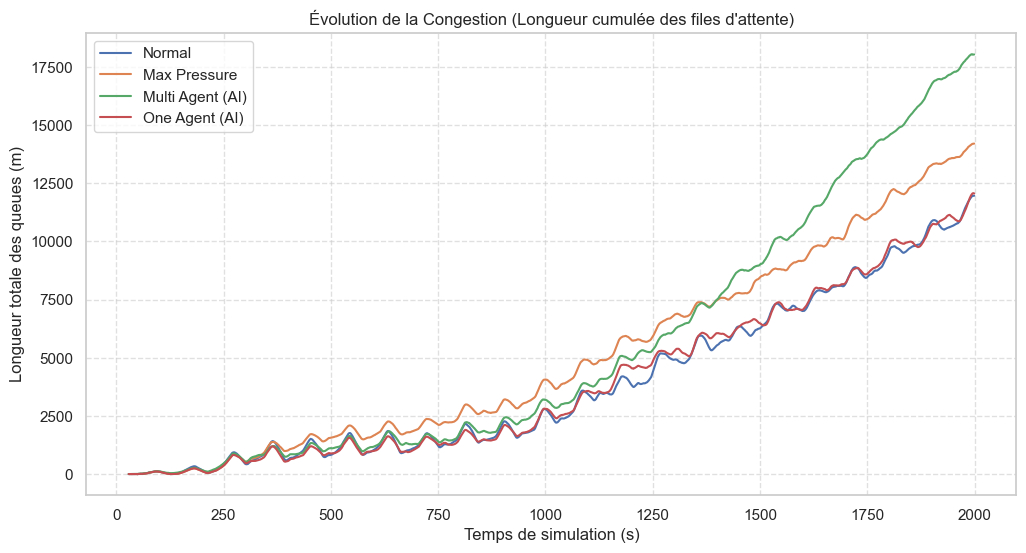

In [38]:
def parse_queue_data(filename):
    """
    Lit le fichier queue-output et calcule la longueur totale 
    de queue dans le réseau à chaque pas de temps.
    """
    if not os.path.exists(filename):
        print(f"Fichier manquant : {filename}")
        return [], []

    tree = ET.parse(filename)
    root = tree.getroot()
    
    timesteps = []
    total_queues = []
    
    # Le fichier est structuré par <data timestep="...">
    for data in root.findall('data'):
        time = float(data.get('timestep'))
        
        current_total_q = 0.0
        # On regarde chaque 'lane' (voie) dans ce pas de temps
        for lane in data.findall('lanes/lane'):
            # queueing_length est en mètres
            q_len = float(lane.get('queueing_length'))
            current_total_q += q_len
            
        timesteps.append(time)
        total_queues.append(current_total_q)
        
    return timesteps, total_queues

def plot_queue_evolution(files_dict):
    plt.figure(figsize=(12, 6))
    
    for strategy, filepath in files_dict.items():
        times, queues = parse_queue_data(filepath)
        if times:
            # On lisse un peu la courbe (moyenne mobile sur 30 sec) pour que ce soit lisible
            series = pd.Series(queues).rolling(window=30).mean()
            plt.plot(times, series, label=strategy)
    
    plt.title("Évolution de la Congestion (Longueur cumulée des files d'attente)")
    plt.xlabel("Temps de simulation (s)")
    plt.ylabel("Longueur totale des queues (m)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.savefig("outputs/kpi_queues_evolution.png")
    plt.show()

# --- DANS LE MAIN ---
if __name__ == "__main__":
    # Définir tes fichiers
    files_queues = {
        "Normal": "outputs/queues_normal.xml",
        "Max Pressure": "outputs/queues_maxpressure.xml",
        "Multi Agent (AI)": "outputs/queues_multi_agent_ai_4380_epochs.xml",
        "One Agent (AI)": "outputs/queues_one_agent_ai_1000_epochs.xml"
    }
    
    # Tracer le graphique
    plot_queue_evolution(files_queues)

Traitement de outputs/emissions_normal.xml...
Traitement de outputs/emissions_maxpressure.xml...
Traitement de outputs/emissions_multi_agent_ai_4380_epochs.xml...
Traitement de outputs/emissions_one_agent_ai_1000_epochs.xml...


C:\Users\celes\AppData\Local\Temp\ipykernel_10200\930840190.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Strategie", y="Total CO2 (kg)", data=df_summary, palette="viridis")


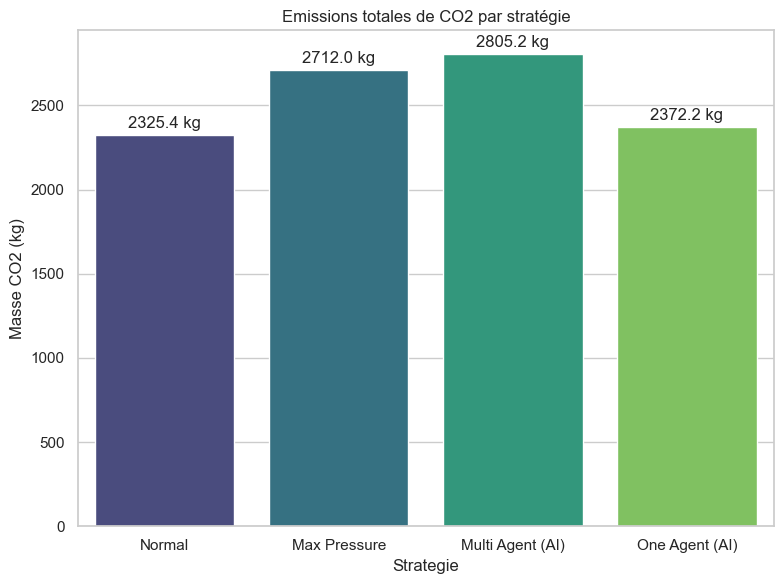

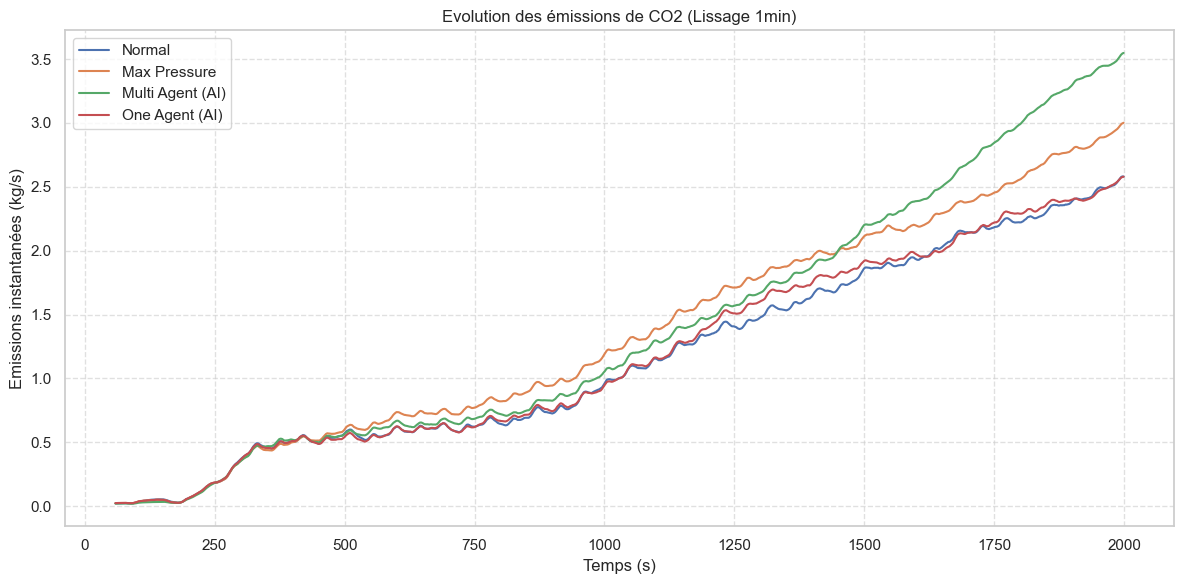

In [40]:
def parse_emission_data(filename):
    """
    Lit le fichier XML emission-output via iterparse (mémoire efficace).
    Retourne un DataFrame avec les émissions agrégées par seconde.
    """
    if not os.path.exists(filename):
        print(f"Fichier introuvable : {filename}")
        return None

    print(f"Traitement de {filename}...")
    
    context = ET.iterparse(filename, events=("start", "end"))
    context = iter(context)
    _, root = next(context)

    data = []
    step_vals = {"CO2": 0.0, "Fuel": 0.0, "NOx": 0.0}
    current_time = 0.0

    for event, elem in context:
        if event == "end" and elem.tag == "timestep":
            current_time = float(elem.get("time"))
            
            data.append({
                "time": current_time,
                "CO2": step_vals["CO2"],
                "Fuel": step_vals["Fuel"],
                "NOx": step_vals["NOx"]
            })
            
            # Reset des compteurs
            step_vals = {"CO2": 0.0, "Fuel": 0.0, "NOx": 0.0}
            root.clear() # Libération mémoire
            
        elif event == "end" and elem.tag == "vehicle":
            step_vals["CO2"] += float(elem.get("CO2", 0))
            step_vals["Fuel"] += float(elem.get("fuel", 0))
            step_vals["NOx"] += float(elem.get("NOx", 0))

    if not data:
        return None

    df = pd.DataFrame(data)
    
    # Conversions unités (mg -> kg, ml -> L)
    df["CO2_kg"] = df["CO2"] / 1_000_000
    df["Fuel_L"] = df["Fuel"] / 1_000
    
    return df

def plot_total_emissions(data_dict):
    """Bar chart des émissions cumulées."""
    summary = []
    for name, df in data_dict.items():
        if df is not None:
            summary.append({
                "Strategie": name,
                "Total CO2 (kg)": df["CO2_kg"].sum()
            })
    
    if not summary: return

    df_summary = pd.DataFrame(summary)
    
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x="Strategie", y="Total CO2 (kg)", data=df_summary, palette="viridis")
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f kg', padding=3)
        
    plt.title("Emissions totales de CO2 par stratégie")
    plt.ylabel("Masse CO2 (kg)")
    plt.tight_layout()
    plt.savefig("outputs/kpi_emissions_total.png")
    plt.show()

def plot_emission_evolution(data_dict):
    """Line chart de l'évolution temporelle (moyenne mobile)."""
    plt.figure(figsize=(12, 6))
    has_data = False

    for name, df in data_dict.items():
        if df is not None:
            has_data = True
            # Lissage sur 60 secondes
            smoothed = df["CO2_kg"].rolling(window=60).mean()
            plt.plot(df["time"], smoothed, label=name)

    if has_data:
        plt.title("Evolution des émissions de CO2 (Lissage 1min)")
        plt.xlabel("Temps (s)")
        plt.ylabel("Emissions instantanées (kg/s)")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.savefig("outputs/kpi_emissions_evolution.png")
        plt.show()

if __name__ == "__main__":
    # Définition des fichiers sources
    files = {
        "Normal": "outputs/emissions_normal.xml",
        "Max Pressure": "outputs/emissions_maxpressure.xml",
        "Multi Agent (AI)": "outputs/emissions_multi_agent_ai_4380_epochs.xml",
        "One Agent (AI)": "outputs/emissions_one_agent_ai_1000_epochs.xml"
    }
    
    results = {}
    for strategy, filepath in files.items():
        results[strategy] = parse_emission_data(filepath)
    
    # Génération des graphiques
    plot_total_emissions(results)
    plot_emission_evolution(results)


METRIQUE             | NORMAL       | MAX PRESS    | MULTI AGENT  | ONE AGENT   
-------------------------------------------------------------------------------------
Total Collisions     | 0            | 0            | 1            | 2           

Graphique sauvegardé : outputs/comparison_collisions.png


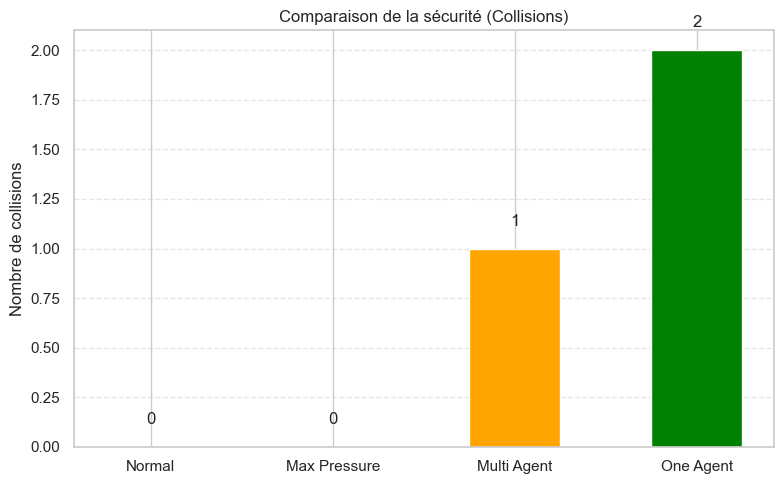

In [12]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import os

def parse_collisions(filename):
    # Compte le nombre total de collisions enregistrées
    if not os.path.exists(filename):
        print(f"Fichier introuvable : {filename}")
        return 0

    try:
        tree = ET.parse(filename)
        root = tree.getroot()
        # On compte simplement le nombre de balises <collision>
        return len(root.findall('collision'))
    except:
        print(f"Erreur de lecture sur {filename}")
        return 0

def print_collision_stats(n_norm, n_mp, n_multi, n_one):
    # Affichage textuel
    print("\n" + "="*85)
    print(f"{'METRIQUE':<20} | {'NORMAL':<12} | {'MAX PRESS':<12} | {'MULTI AGENT':<12} | {'ONE AGENT':<12}")
    print("-" * 85)
    
    print(f"{'Total Collisions':<20} | {n_norm:<12} | {n_mp:<12} | {n_multi:<12} | {n_one:<12}")
    print("="*85 + "\n")

def plot_collisions(n_norm, n_mp, n_multi, n_one):
    # Graphique dédié aux collisions (souvent 0 ou très peu, donc un graphe à part est mieux)
    strategies = ['Normal', 'Max Pressure', 'Multi Agent', 'One Agent']
    values = [n_norm, n_mp, n_multi, n_one]
    colors = ['gray', 'blue', 'orange', 'green']

    plt.figure(figsize=(8, 5))
    bars = plt.bar(strategies, values, color=colors, width=0.5)

    plt.ylabel('Nombre de collisions')
    plt.title('Comparaison de la sécurité (Collisions)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Ajout des valeurs au dessus des barres
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig("outputs/comparison_collisions.png")
    print("Graphique sauvegardé : outputs/comparison_collisions.png")
    plt.show()

if __name__ == "__main__":
    # Noms des fichiers collisions (à adapter selon ta config SUMO)
    # Assure-toi d'avoir ajouté --collision-output collisions.xml dans tes commandes SUMO
    c_norm = parse_collisions("outputs/collisions_normal.xml")
    c_mp = parse_collisions("outputs/collisions_maxpressure.xml")
    c_multi = parse_collisions("outputs/collisions_multi_agent_ai_4380_epochs.xml")
    c_one = parse_collisions("outputs/collisions_one_agent_ai_1000_epochs.xml")

    # Affichage des résultats
    print_collision_stats(c_norm, c_mp, c_multi, c_one)
    
    # Génération du graphe seulement s'il y a des collisions à montrer
    if (c_norm + c_mp + c_multi + c_one) > 0:
        plot_collisions(c_norm, c_mp, c_multi, c_one)
    else:
        print("Aucune collision détectée sur l'ensemble des simulations.")

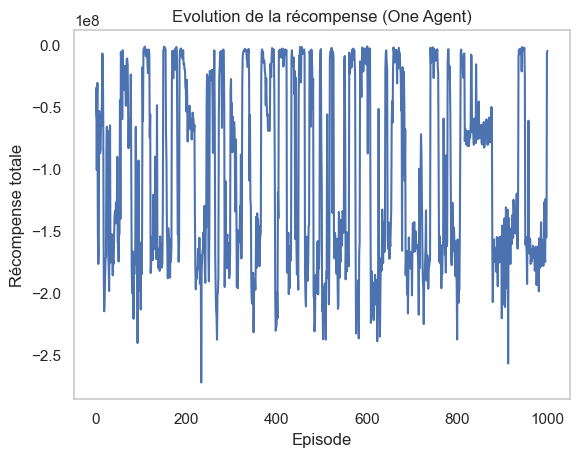

In [20]:

import pandas as pd
import matplotlib.pyplot as plt

# 1. On charge le fichier en précisant header=None
# 2. On donne la liste des noms dans l'ordre exact des colonnes
df_log = pd.read_csv("outputs/training_log_one_agent.csv", header=None, names=["episode", "avg_wait", "reward"])

# Maintenant tu peux l'utiliser normalement
plt.plot(df_log['episode'], df_log['reward'])
plt.title("Evolution de la récompense (One Agent)")
plt.xlabel("Episode")
plt.ylabel("Récompense totale")
plt.grid()
plt.show()
